## 1) Install the necessary librarys

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import (CountVectorizer,TfidfVectorizer,HashingVectorizer)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

## 2) Load the dataset

In [3]:
dataset = pd.read_csv("news.csv", index_col=None)

In [4]:
dataset

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


In [5]:
#Remove the extra useless data
df=dataset.drop("Unnamed: 0", axis=1)

In [6]:
#print(df.head())
print(df.shape)
print(df.columns)

(6335, 3)
Index(['title', 'text', 'label'], dtype='object')


## 3) Input & Output split

In [7]:
x=df['text']
y=df['label']

## 4) Split the train and test 

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.33, random_state=53)

## 5) Text Preprocessing 

In [9]:
#Store the Multiple vectorizers model 
vectorizers = {
    "CountVectorizer": CountVectorizer(stop_words="english"),

    "TF-IDF": TfidfVectorizer(stop_words="english"),

    "HashingVectorizer": HashingVectorizer(stop_words="english",n_features=2**12,alternate_sign=False)
}

## 6) Model creation

In [10]:
#Store the Multiple models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),

    "Linear SVM": LinearSVC(),

    "Multinomial NB": MultinomialNB(),

    "Complement NB": ComplementNB(),

    "SGD Classifier": SGDClassifier(random_state=42),
}

In [11]:
#Run the Multiple vectorizers and modes 
results = []

for vectorizer_name, vectorizer in vectorizers.items():

    for model_name, model in models.items():

        print(f"Training: {vectorizer_name} + {model_name}")

        pipeline = Pipeline([
            ("vectorizer", vectorizer),
            ("model", model)
        ])

        pipeline.fit(x_train, y_train)

        y_pred = pipeline.predict(x_test)

        accuracy = accuracy_score(y_test, y_pred)

        precision = precision_score(y_test,y_pred,average="weighted",zero_division=0)

        recall = recall_score(y_test,y_pred,average="weighted",zero_division=0)

        f1 = f1_score(y_test,y_pred,average="weighted",zero_division=0)

        results.append({
            "Vectorizer": vectorizer_name,
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })

Training: CountVectorizer + Logistic Regression
Training: CountVectorizer + Linear SVM


C:\Users\smani\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training: CountVectorizer + Multinomial NB
Training: CountVectorizer + Complement NB
Training: CountVectorizer + SGD Classifier
Training: TF-IDF + Logistic Regression
Training: TF-IDF + Linear SVM
Training: TF-IDF + Multinomial NB
Training: TF-IDF + Complement NB
Training: TF-IDF + SGD Classifier
Training: HashingVectorizer + Logistic Regression
Training: HashingVectorizer + Linear SVM
Training: HashingVectorizer + Multinomial NB
Training: HashingVectorizer + Complement NB
Training: HashingVectorizer + SGD Classifier


In [12]:
#save the result in data table
results_df = pd.DataFrame(results)

#Show the best result in F1 
print(results_df.sort_values("F1", ascending=False))

           Vectorizer                Model  Accuracy  Precision    Recall  \
9              TF-IDF       SGD Classifier  0.937829   0.938555  0.937829   
6              TF-IDF           Linear SVM  0.936394   0.937722  0.936394   
5              TF-IDF  Logistic Regression  0.913917   0.917117  0.913917   
0     CountVectorizer  Logistic Regression  0.911047   0.912995  0.911047   
4     CountVectorizer       SGD Classifier  0.911047   0.911041  0.911047   
11  HashingVectorizer           Linear SVM  0.903874   0.904502  0.903874   
14  HashingVectorizer       SGD Classifier  0.900048   0.900560  0.900048   
2     CountVectorizer       Multinomial NB  0.893352   0.894561  0.893352   
3     CountVectorizer        Complement NB  0.893352   0.894561  0.893352   
10  HashingVectorizer  Logistic Regression  0.889048   0.891282  0.889048   
1     CountVectorizer           Linear SVM  0.879005   0.879417  0.879005   
12  HashingVectorizer       Multinomial NB  0.869919   0.869976  0.869919   

## 7)GridSearchCV

### A) CountVectorizer + algorithms

In [13]:
count_params = {"vectorizer__ngram_range": [(1, 1), (1, 2)]}

tfidf_params = {"vectorizer__ngram_range": [(1, 1), (1, 2)],"vectorizer__sublinear_tf": [True]}

hash_params = {"vectorizer__n_features": [2**12],"vectorizer__alternate_sign": [False]}


### B) Model parameters

In [14]:
logistic_params = {"model__C": [0.1, 1, 10]}

svm_params = {"model__C": [0.1, 1, 10]}

nb_params = {"model__alpha": [0.1, 0.5, 1.0]}

complement_params = {"model__alpha": [0.1, 0.5, 1.0]}

sgd_params = {"model__alpha": [0.0001, 0.001],"model__loss": ["hinge"]}

### C) Create parameter dictionary

In [15]:
model_params = {
    "Logistic Regression": logistic_params,
    "Linear SVM": svm_params,
    "Multinomial NB": nb_params,
    "Complement NB": complement_params,
    "SGD Classifier": sgd_params
}

vectorizer_params = {
    "CountVectorizer": count_params,
    "TF-IDF": tfidf_params,
    "HashingVectorizer": hash_params
}

### D) Run GridSearchCV

In [16]:
grid_results = []

best_models = {}

for vectorizer_name, vectorizer in vectorizers.items():

    for model_name, model in models.items():

        print("\n" + "=" * 70)
        print(f"Vectorizer : {vectorizer_name}")
        print(f"Model      : {model_name}")
        print("=" * 70)

        pipeline = Pipeline([("vectorizer", vectorizer),("model", model)])

        params = {}

        params.update(vectorizer_params[vectorizer_name])
        params.update(model_params[model_name])

        grid = GridSearchCV(estimator=pipeline, param_grid=params, cv=3, scoring="f1_weighted", n_jobs=-1, verbose=1)

        grid.fit(x_train, y_train)

        print("Best Parameters:")
        print(grid.best_params_)

        print("Best CV Score:")
        print(grid.best_score_)

        # Test set prediction
        y_pred = grid.predict(x_test)

        accuracy = accuracy_score(y_test, y_pred)

        precision = precision_score(y_test,y_pred,average="weighted",zero_division=0)

        recall = recall_score(y_test,y_pred,average="weighted",zero_division=0)

        f1 = f1_score(y_test,y_pred,average="weighted",zero_division=0)

        grid_results.append({
            "Vectorizer": vectorizer_name,
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "CV Score": grid.best_score_,
            "Best Parameters": grid.best_params_
        })

        best_models[f"{vectorizer_name} + {model_name}"] = grid.best_estimator_



Vectorizer : CountVectorizer
Model      : Logistic Regression
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters:
{'model__C': 0.1, 'vectorizer__ngram_range': (1, 2)}
Best CV Score:
0.9186124176578184

Vectorizer : CountVectorizer
Model      : Linear SVM
Fitting 3 folds for each of 6 candidates, totalling 18 fits


C:\Users\smani\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best Parameters:
{'model__C': 0.1, 'vectorizer__ngram_range': (1, 2)}
Best CV Score:
0.8952816773920552

Vectorizer : CountVectorizer
Model      : Multinomial NB
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters:
{'model__alpha': 0.1, 'vectorizer__ngram_range': (1, 2)}
Best CV Score:
0.913873673819193

Vectorizer : CountVectorizer
Model      : Complement NB
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters:
{'model__alpha': 0.1, 'vectorizer__ngram_range': (1, 2)}
Best CV Score:
0.913873673819193

Vectorizer : CountVectorizer
Model      : SGD Classifier
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Parameters:
{'model__alpha': 0.0001, 'model__loss': 'hinge', 'vectorizer__ngram_range': (1, 2)}
Best CV Score:
0.9118768409022757

Vectorizer : TF-IDF
Model      : Logistic Regression
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters:
{'model__C': 10, 'vectorizer__ngram_range': (1, 1), 'vectorizer

## 7) Evaluation metrics

In [17]:
#Compare all models
grid_results_df = pd.DataFrame(grid_results)

grid_results_df = grid_results_df.sort_values(by="F1",ascending=False)

print(
    grid_results_df[
        [
            "Vectorizer",
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "CV Score"
        ]
    ]
)

           Vectorizer                Model  Accuracy  Precision    Recall  \
6              TF-IDF           Linear SVM  0.942133   0.942826  0.942133   
9              TF-IDF       SGD Classifier  0.942133   0.942531  0.942133   
5              TF-IDF  Logistic Regression  0.938307   0.939458  0.938307   
0     CountVectorizer  Logistic Regression  0.923482   0.926442  0.923482   
7              TF-IDF       Multinomial NB  0.917743   0.924199  0.917743   
8              TF-IDF        Complement NB  0.917264   0.923814  0.917264   
4     CountVectorizer       SGD Classifier  0.915830   0.915945  0.915830   
2     CountVectorizer       Multinomial NB  0.915830   0.918431  0.915830   
3     CountVectorizer        Complement NB  0.915352   0.918013  0.915352   
10  HashingVectorizer  Logistic Regression  0.905308   0.905967  0.905308   
11  HashingVectorizer           Linear SVM  0.903874   0.904502  0.903874   
1     CountVectorizer           Linear SVM  0.900526   0.903671  0.900526   

In [18]:
#Find the best model
best_row = grid_results_df.iloc[0]

print("Best Vectorizer:", best_row["Vectorizer"])
print("Best Model:", best_row["Model"])
print("Best Accuracy:", best_row["Accuracy"])
print("Best F1:", best_row["F1"])
print("Best Parameters:", best_row["Best Parameters"])

Best Vectorizer: TF-IDF
Best Model: Linear SVM
Best Accuracy: 0.9421329507412721
Best F1: 0.9421515381619928
Best Parameters: {'model__C': 1, 'vectorizer__ngram_range': (1, 1), 'vectorizer__sublinear_tf': True}


In [20]:
#Classification report 
best_name = (f"{best_row['Vectorizer']} + "f"{best_row['Model']}")

best_model = best_models[best_name]

y_pred = best_model.predict(x_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

        FAKE       0.92      0.96      0.94      1008
        REAL       0.96      0.93      0.94      1083

    accuracy                           0.94      2091
   macro avg       0.94      0.94      0.94      2091
weighted avg       0.94      0.94      0.94      2091



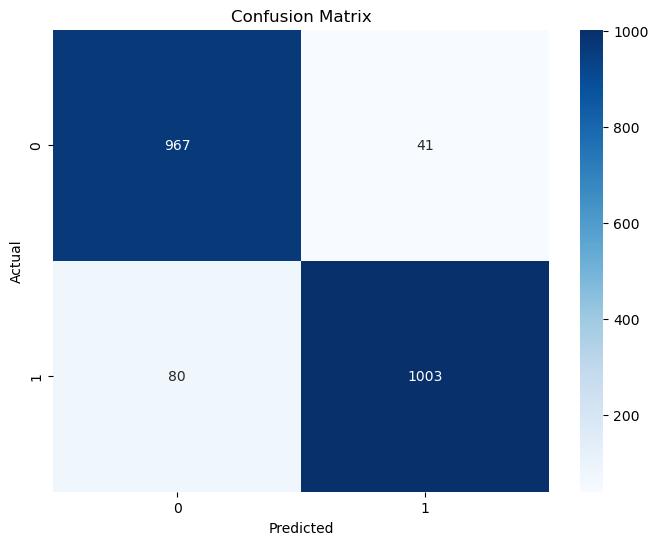

In [21]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


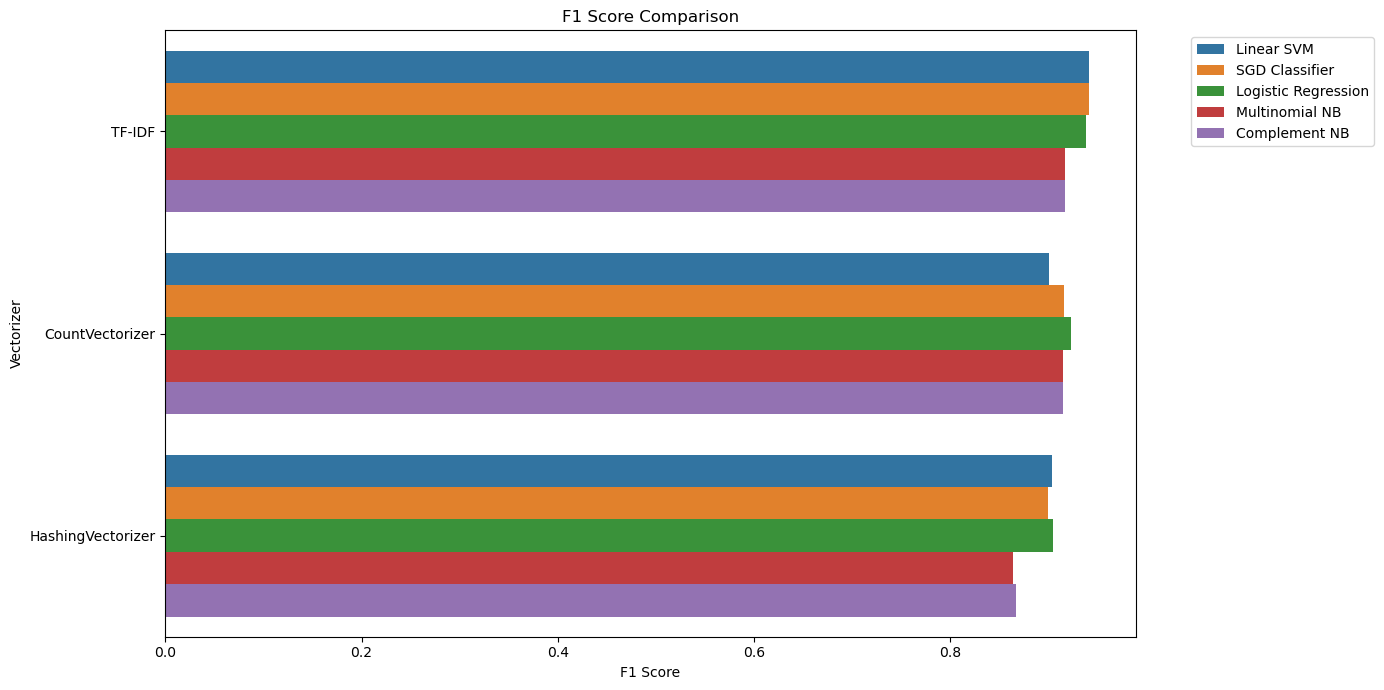

In [22]:
#Compare models visually
plt.figure(figsize=(14, 7))

sns.barplot(
    data=grid_results_df,
    x="F1",
    y="Vectorizer",
    hue="Model"
)

plt.title("F1 Score Comparison")
plt.xlabel("F1 Score")
plt.ylabel("Vectorizer")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


## 8) Save the best model

In [23]:
joblib.dump(best_model,"best_nlp_model.pkl")

['best_nlp_model.pkl']